In this kata, you will write a function that returns the positions and the values of the "peaks" (or local maxima) of a numeric array.

For example, the array arr = [0, 1, 2, 5, 1, 0] has a peak at position 3 with a value of 5 (since arr[3] equals 5).

The output will be returned as an object with two properties: pos and peaks. Both of these properties should be arrays. If there is no peak in the given array, then the output should be {pos: [], peaks: []}.

Example: pickPeaks([3, 2, 3, 6, 4, 1, 2, 3, 2, 1, 2, 3]) should return {pos: [3, 7], peaks: [6, 3]} (or equivalent in other languages)

All input arrays will be valid integer arrays (although it could still be empty), so you won't need to validate the input.

The first and last elements of the array will not be considered as peaks (in the context of a mathematical function, we don't know what is after and before and therefore, we don't know if it is a peak or not).

Also, beware of plateaus !!! [1, 2, 2, 2, 1] has a peak while [1, 2, 2, 2, 3] and [1, 2, 2, 2, 2] do not. In case of a plateau-peak, please only return the position and value of the beginning of the plateau. For example: pickPeaks([1, 2, 2, 2, 1]) returns {pos: [1], peaks: [2]} (or equivalent in other languages)

Have fun!

Ideas.

* First let's get a visualisation going to help visualise where the peaks are.
* We need to formalise what it means for there to be a local maximum by looking at the picture.
* Recall that in calculus, a stationary has derivative 0, and then we do tests either side.
* A number $x_n$ is a peak if:
    * It is not the first nor last number in the array.
    * If $x_{n-1}$ increases to $x_n$, so that $l = x_n - x_{n-1} > 0$.
    * And $x_{n}$ is the same as, or decreases to $x_{n+1}$, so that $r = x_{n+1} - x_{n} < 0$.
    * For an array with $x = [x_0 \dots, x_{n-1}]$ of length $n$, only compute $l$ and $r$ for $x_1, \dots, x_{n-2}$
To code this up.
* Pass a sliding window of length 3 across the whole array, and run the above test, then record value and index.
    * But here you'd be doubling the amount of computation, as computing $r$ twice.
* So cache the computation instead by running through $x_1, \dots x_{n-1}$, and storing the $l$ computed in each step as the next $r$

In [1]:
import matplotlib.pyplot as plt

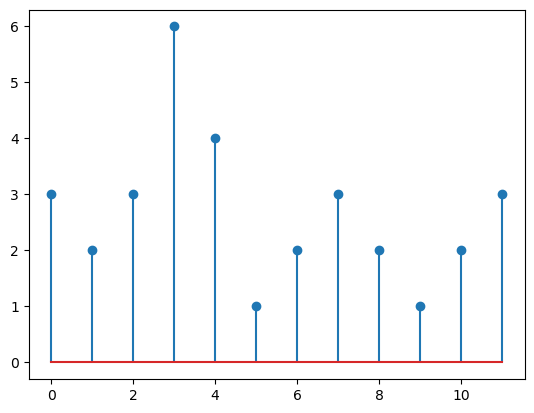

In [2]:
arr = [3,2,3,6,4,1,2,3,2,1,2,3]
pos = [i for i in range(len(arr))]
fig, ax = plt.subplots()
ax = plt.stem(pos, arr)

In [3]:
arr = [3,2,3,6,4,1,2,3,2,1,2,3]
positions = []
peaks = []

# For every number in the array between index 1 and index (len(arr)) - 2, we compute l and r.
# This means that we have excluded the first and last elements of the array.

l = arr[1] - arr[0]
for i in range(1, len(arr) - 2):
    r = arr[i+1] - arr[i]

    if l > 0 and r <= 0:
        positions.append(i)
        peaks.append(arr[i])

    l = r

In [4]:
print(positions, peaks)

[3, 7] [6, 3]


* Refinement - dealing with plateaus.
* Code above will not work for e.g: [1,2,5,4,3,2,3,6,4,1,2,3,3,4,5,3,2,1,2,3,5,5,4,3].
* Notice below that your code will incorrectly detect index 11 as a peak, when it isn't.
* We need to amend the logic, so that the code doesn't book a peak.
* A number $x_n$ is a peak if:
    * It is not the first nor last number in the array.
    * If $x_{n-1}$ increases to $x_n$, so that $l = x_n - x_{n-1} > 0$.
    * And $x_{n}$ is the same as, or decreases to $x_{n+1}$, so that $r = x_{n+1} - x_{n} < 0$.
    * For an array with $x = [x_0 \dots, x_{n-1}]$ of length $n$, only compute $l$ and $r$ for $x_1, \dots, x_{n-2}$.
* However, we need to deal when we have a plateau.
* A plateau begins at index $n$ when $l > 0$ and $r = 0$ -> store the index to compare later.
* A plateau continues if $l = 0$ and $r = 0$ for the current index
* A plateau ends if $l = 0$ and $r \neq 0$, and there is a stored index for comparison (to deal with plateaus starting at beginning).
    * If $r > 0$ then the stored index is not a peak.
    * If $r < 0$ then the stored index is a peak.

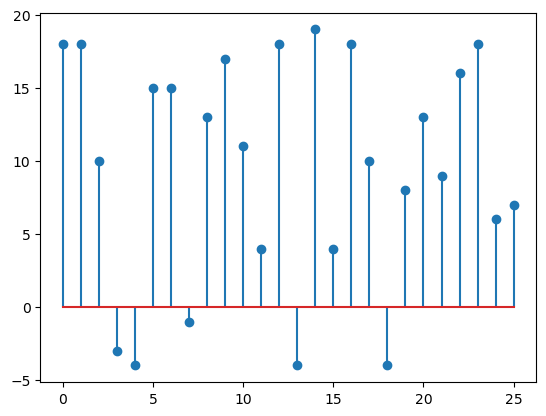

In [5]:
arr = [18, 18, 10, -3, -4, 15, 15, -1, 13, 17, 11, 4, 18, -4, 19, 4, 18, 10, -4, 8, 13, 9, 16, 18, 6, 7]
pos = [i for i in range(len(arr))]
fig, ax = plt.subplots()
ax = plt.stem(pos, arr)

In [20]:
arr = [18, 18, 10, -3, -4, 15, 15, -1, 13, 17, 11, 4, 18, -4, 19, 4, 18, 10, -4, 8, 13, 9, 16, 18, 6, 7]
positions = []
peaks = []

# For every number in the array between index 1 and index (len(arr)) - 1 inclusive, we compute l and r.
# This means that we have excluded the first and last elements of the array.
candidate_pos = None
l = arr[1] - arr[0]
for i in range(1, len(arr) - 1):
    r = arr[i+1] - arr[i]

    # Check if current number is an unambiguous peak.
    if l > 0 and r < 0:
        positions.append(i)
        peaks.append(arr[i])

    # Check if current number starts a plateau, if so, store.
    if l > 0 and r == 0:
        candidate_pos = i
    
    # Check if a plateau has ended, with stored number as peak, or not.
    if l == 0 and r < 0 and candidate_pos:
        positions.append(candidate_pos)
        peaks.append(arr[candidate_pos])

    l = r

In [ ]:
def pick_peaks(arr):
    positions = []
    peaks = []
    
    # Empty array edge case.
    if not arr:
        return {"pos": positions, "peaks": peaks}

    # Compute left and right differences for each number, excluding first and last.
    candidate_pos = None
    l = arr[1] - arr[0]
    
    for i in range(1, len(arr) - 1):
        r = arr[i+1] - arr[i]

    # Check if current number is an unambiguous peak.
        if l > 0 and r < 0:
            positions.append(i)
            peaks.append(arr[i])

    # Check if current number starts a plateau, if so, store.
        if l > 0 and r == 0:
            candidate_pos = i
    
    # Check if a plateau has ended, with stored number as peak, or not.
        if l == 0 and r < 0 and candidate_pos:
            positions.append(candidate_pos)
            peaks.append(arr[candidate_pos])
    
    # The right difference is cached for re-use.
        l = r
    
    return {"pos": positions, "peaks": peaks}